In [1]:
import os, re
import numpy as np

# plotting styles
import matplotlib as mpl
from matplotlib import pyplot as plt

%matplotlib inline

mpl.rcParams['figure.dpi']= 150

In [2]:
import h5py

with h5py.File("../data/dr12q/processed/dla_samples_a03.mat", "r") as f:
    print(f.keys())
    # <KeysViewHDF5 ['alpha', 'fit_max_log_nhi', 'fit_min_log_nhi', 'log_nhi_samples', 'nhi_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
    # log_nhi_samples.shape: (10000, 1)
    # alpha.shape: (1, 1)
    # offset_samples.shape: (10000, 1)
    # fit_min_log_nhi.shape: (1, 1)
    # fit_max_log_nhi.shape: (1, 1)
    # uniform_min_log_nhi.shape: (1, 1) 
    log_nhi_samples = f["log_nhi_samples"][:]
    alpha = f["alpha"][:]
    offset_samples = f["offset_samples"][:]
    fit_min_log_nhi = f["fit_min_log_nhi"][:]
    fit_max_log_nhi = f["fit_max_log_nhi"][:]
    uniform_min_log_nhi = f["uniform_min_log_nhi"][:]
    uniform_max_log_nhi = f["uniform_max_log_nhi"][:]
    nhi_samples = f["nhi_samples"][:]
    print("log_nhi_samples.shape:", log_nhi_samples.shape)
    print("alpha.shape:", alpha.shape)
    print("offset_samples.shape:", offset_samples.shape)
    print("fit_min_log_nhi.shape:", fit_min_log_nhi.shape)
    print("fit_max_log_nhi.shape:", fit_max_log_nhi.shape)
    print("uniform_min_log_nhi.shape:", uniform_min_log_nhi.shape)

<KeysViewHDF5 ['alpha', 'fit_max_log_nhi', 'fit_min_log_nhi', 'log_nhi_samples', 'nhi_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
log_nhi_samples.shape: (10000, 1)
alpha.shape: (1, 1)
offset_samples.shape: (10000, 1)
fit_min_log_nhi.shape: (1, 1)
fit_max_log_nhi.shape: (1, 1)
uniform_min_log_nhi.shape: (1, 1)


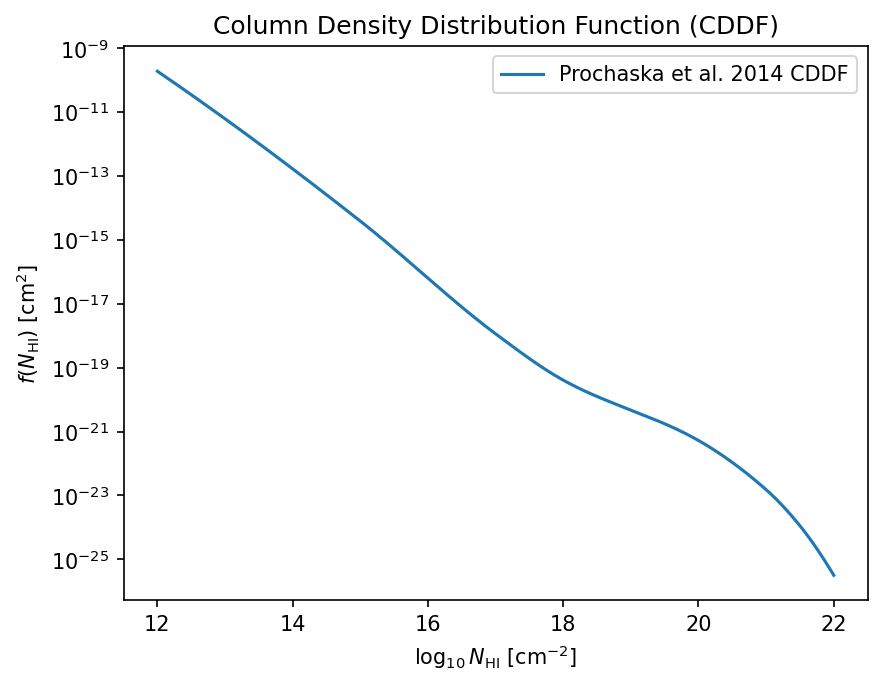

In [3]:
import numpy as np
from scipy.interpolate import PchipInterpolator

# From Table 2 (Results for Spline Model — Figure 7)
logN_nodes = np.array([12.0, 15.0, 17.0, 18.0, 
                       20.0, 21.0, 21.5, 22.0])
logf_nodes = np.array([-9.72, -14.41, -17.94, -19.39,
                       -21.28, -22.82, -23.95, -25.50])

# Paper specifies cubic Hermite spline (Fritsch & Carlson 1980)
cddf_spline = PchipInterpolator(logN_nodes, logf_nodes)

def log10_f_cddf(logN):
    """
    CDDF used in Figure 7 of Prochaska et al. 2014.
    A cubic Hermite spline defined by Table 2 (Spline Model).
    """
    logN = np.asarray(logN)
    logN_clip = np.clip(logN, logN_nodes[0], logN_nodes[-1])
    return cddf_spline(logN_clip)

def f_cddf(logN):
    return 10**log10_f_cddf(logN)

# plot the CDDF from Prochaska et al. 2014
logN_plot = np.linspace(12.0, 22.0, 500)
plt.plot(logN_plot, f_cddf(logN_plot), label="Prochaska et al. 2014 CDDF")
plt.yscale("log")
plt.xlabel(r"$\log_{10} N_{\mathrm{HI}}$ [cm$^{-2}$]")
plt.ylabel(r"$f(N_{\mathrm{HI}})$ [cm$^{2}$]")
plt.title("Column Density Distribution Function (CDDF)")
plt.legend()

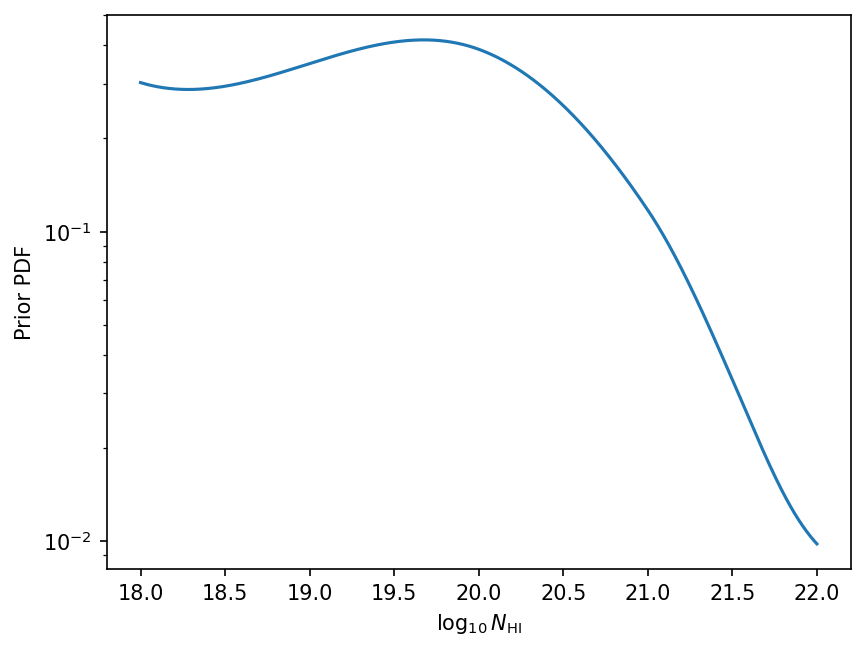

Integral of prior over range (quad): 0.9999999999999999


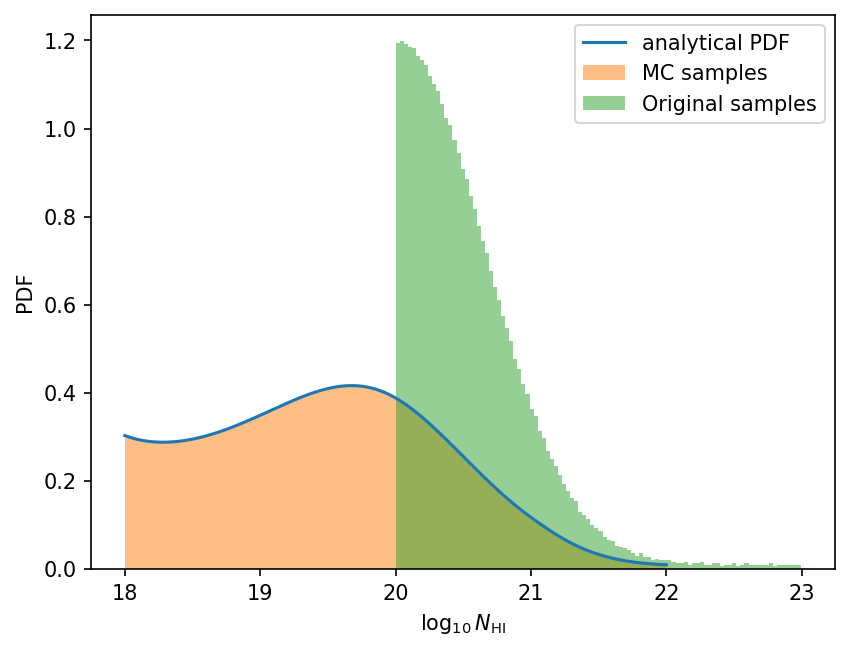

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import PchipInterpolator
from scipy.stats.qmc import Halton
from scipy.interpolate import interp1d

# --------------------------
# 1. PW14 CDDF (Figure 7)
# --------------------------

# Node locations in log10 N_HI (cm^-2), from Table 2, "Spline Model (Figure 7)"
logN_nodes = np.array([12.0, 15.0, 17.0, 18.0,
                       20.0, 21.0, 21.5, 22.0])

# Corresponding log10 f(N_HI, X)
logf_nodes = np.array([-9.72, -14.41, -17.94, -19.39,
                       -21.28, -22.82, -23.95, -25.50])

# Monotonic cubic Hermite spline (similar to Fritsch–Carlson)
_cddf_spline = PchipInterpolator(logN_nodes, logf_nodes)

def log10_f_pw14(logN):
    """
    Prochaska+14 (2014) spline CDDF (Fig. 7) at pivot redshift.
    Returns log10 f(N_HI, X), with logN = log10 N_HI.
    """
    logN = np.asarray(logN)
    logN_clip = np.clip(logN, logN_nodes[0], logN_nodes[-1])
    return _cddf_spline(logN_clip)

def f_pw14(logN):
    """Linear f(N_HI, X) from the spline."""
    return 10.0 ** log10_f_pw14(logN)


# --------------------------
# 2. Build prior p(log N_HI)
# --------------------------

# Mixture weight: a fraction from PW14, (1-a) from uniform
a = 0.97  # set a = 1.0 for pure PW14 prior

# Prior range in log10 N_HI (you said 17–23; old code used 19.8–22.6)
prior_min_log_nhi = 18.0
prior_max_log_nhi = 22.0

def unnormalized_pw14_logN_pdf(log_nhi):
    """
    Unnormalized PDF in log10 N_HI derived from PW14 CDDF:

        p(logN) ∝ f(N) * N * ln(10)

    where f(N) is per linear N.
    """
    log_nhi = np.asarray(log_nhi)
    N = 10.0 ** log_nhi
    return f_pw14(log_nhi) * N * np.log(10.0)

# Normalize PW14 part over the chosen range
Z_pw14 = quad(unnormalized_pw14_logN_pdf,
              prior_min_log_nhi,
              prior_max_log_nhi)[0]

def normalized_pw14_pdf(log_nhi):
    return unnormalized_pw14_logN_pdf(log_nhi) / Z_pw14

def normalized_pdf(log_nhi):
    """
    Final prior in log10 N_HI:
        p(logN) = a * p_PW14(logN) + (1-a) * Uniform
    """
    log_nhi = np.asarray(log_nhi)
    pw = normalized_pw14_pdf(log_nhi)

    # uniform component over [prior_min, prior_max]
    uniform = ((log_nhi >= prior_min_log_nhi) &
               (log_nhi <= prior_max_log_nhi)) / (prior_max_log_nhi - prior_min_log_nhi)

    return a * pw + (1.0 - a) * uniform


# --------------------------
# 3. Sanity check: plot PDF
# --------------------------

log_nhis = np.linspace(prior_min_log_nhi, prior_max_log_nhi, num=1000)
plt.figure()
plt.plot(log_nhis, normalized_pdf(log_nhis))
plt.xlabel(r"$\log_{10} N_{\rm HI}$")
plt.ylabel("Prior PDF")
plt.yscale("log")
plt.show()

print("Integral of prior over range (quad):",
      quad(normalized_pdf, prior_min_log_nhi, prior_max_log_nhi)[0])


# --------------------------
# 4. Sampling with Halton + inverse CDF
# --------------------------

sampler = Halton(
    d=2,       # still 2-D if you use another parameter in dim 2
    scramble=True,
)

np.random.seed(42)
num_samples = 50000
halton_sequence = sampler.random(num_samples)

def build_inverse_cdf(g, min_lognhi=prior_min_log_nhi, max_lognhi=prior_max_log_nhi,
                      n_grid=50000):
    """
    Build inverse CDF for a 1D pdf g(logN) on [min_lognhi, max_lognhi]
    using a dense grid + interpolation.
    """
    x = np.linspace(min_lognhi, max_lognhi, num=n_grid)
    y = g(x)
    cdf_y = np.cumsum(y)
    cdf_y /= cdf_y.max()
    return interp1d(cdf_y, x, bounds_error=False,
                    assume_sorted=True, fill_value=(x[0], x[-1]))

# precompute inverse CDF once
inverse_cdf = build_inverse_cdf(normalized_pdf)

def draw_logN_samples(u):
    """
    Draw samples given uniform(0,1) numbers u using the pre-built inverse CDF.
    """
    return inverse_cdf(u)

samples_log_nhis = draw_logN_samples(halton_sequence[:, 0])

# Compare histogram with analytical PDF
plt.figure()
plt.plot(log_nhis, normalized_pdf(log_nhis), label="analytical PDF")
plt.hist(samples_log_nhis, bins=100, density=True,
         alpha=0.5, label="MC samples")
plt.hist(log_nhi_samples, bins=100, density=True, alpha=0.5, label="Original samples")
plt.xlabel(r"$\log_{10} N_{\rm HI}$")
plt.ylabel("PDF")
plt.legend()
plt.show()

Text(0, 0.5, '$\\log_{10} f(N_{\\rm HI}, X)$')

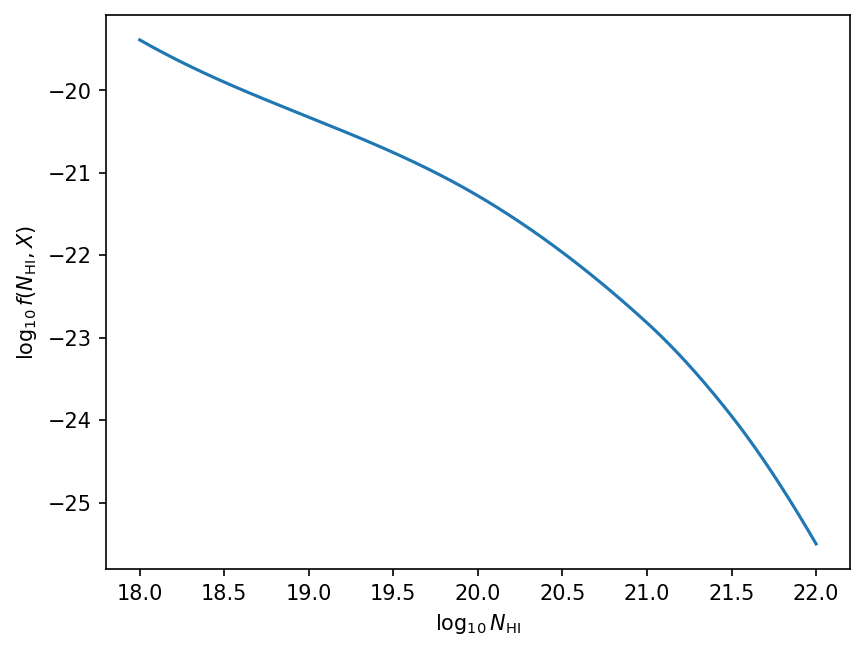

In [5]:
plt.plot(log_nhis, np.log10(f_pw14(log_nhis)))
# plt.plot(log_nhis, normalized_pdf(log_nhis), label="analytical PDF")
plt.xlabel(r"$\log_{10} N_{\rm HI}$")
plt.ylabel(r"$\log_{10} f(N_{\rm HI}, X)$")


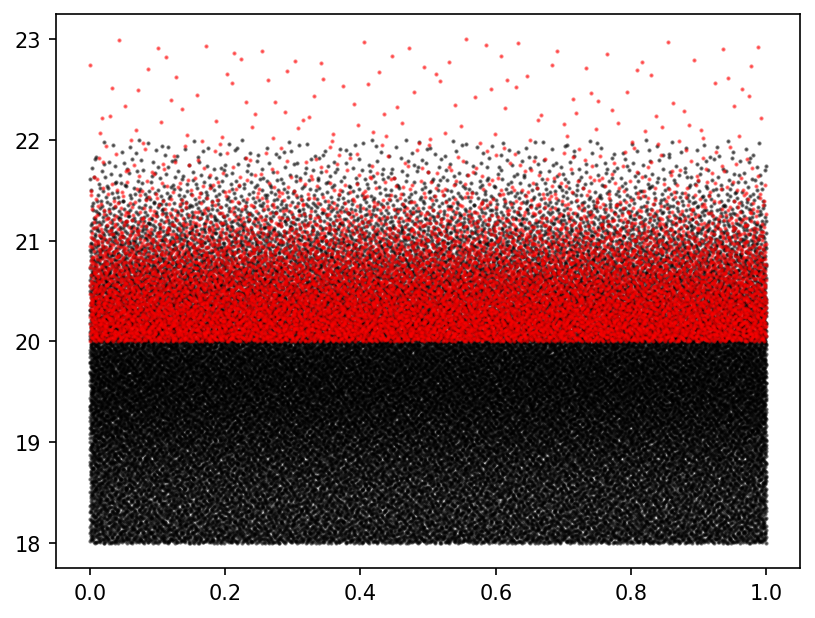

In [6]:
# visualize halton sequence
plt.scatter(
    halton_sequence[:, 1], samples_log_nhis[:], 
    s=1, alpha=0.5, c="black"
)
# original
plt.scatter(
    offset_samples, log_nhi_samples, 
    s=1, alpha=0.5, c="red"
)

Save the samples

In [9]:
# Single model: 18 - 22
import h5py

with h5py.File("../data/dr12q/processed/pw_samples_a{}_{}_{}_{}.mat".format(int((1-a) * 100), int(prior_min_log_nhi*10), int(prior_max_log_nhi*10), num_samples), "w") as f:
    print(f.keys())
    # <KeysViewHDF5 ['alpha', 'fit_max_log_nhi', 'fit_min_log_nhi', 'log_nhi_samples', 'nhi_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
    # log_nhi_samples.shape: (10000, 1)
    # alpha.shape: (1, 1)
    # offset_samples.shape: (10000, 1)
    # fit_min_log_nhi.shape: (1, 1)
    # fit_max_log_nhi.shape: (1, 1)
    # uniform_min_log_nhi.shape: (1, 1) 
    f.create_dataset("log_nhi_samples", data=samples_log_nhis[:, None])
    f.create_dataset("alpha", data=np.array([a])[:, None])
    f.create_dataset("offset_samples", data=halton_sequence[:, 1][:, None])
    f.create_dataset("fit_min_log_nhi", data=np.array([prior_min_log_nhi])[:, None])
    f.create_dataset("fit_max_log_nhi", data=np.array([prior_max_log_nhi])[:, None])
    f.create_dataset("uniform_min_log_nhi", data=np.array([prior_min_log_nhi])[:, None])
    f.create_dataset("uniform_max_log_nhi", data=np.array([prior_max_log_nhi])[:, None])
    f.create_dataset("nhi_samples", data=10**samples_log_nhis[:, None])
    print("Saved samples to ../data/dr12q/processed/pw_samples_a{}_{}_{}_{}.mat".format(int((1-a) * 100), int(prior_min_log_nhi*10), int(prior_max_log_nhi*10), num_samples))

# double check the shape of the samples
with h5py.File("../data/dr12q/processed/pw_samples_a{}_{}_{}_50000.mat".format(int((1-a) * 100), int(prior_min_log_nhi*10), int(prior_max_log_nhi*10)), "r") as f:
    log_nhi_samples = f["log_nhi_samples"][:]
    print("log_nhi_samples.shape:", log_nhi_samples.shape)
    assert log_nhi_samples.shape == (num_samples, 1)
    print("Samples shape is correct.")

    # other variables
    print("alpha.shape:", f["alpha"][:].shape)
    print("offset_samples.shape:", f["offset_samples"][:].shape)
    print("fit_min_log_nhi.shape:", f["fit_min_log_nhi"][:].shape)
    print("fit_max_log_nhi.shape:", f["fit_max_log_nhi"][:].shape)
    print("uniform_min_log_nhi.shape:", f["uniform_min_log_nhi"][:].shape)
    print("uniform_max_log_nhi.shape:", f["uniform_max_log_nhi"][:].shape)
    print("nhi_samples.shape:", f["nhi_samples"][:].shape)
    assert f["nhi_samples"][:].shape == (num_samples, 1)
    print("All shapes are correct.")



<KeysViewHDF5 []>
Saved samples to ../data/dr12q/processed/pw_samples_a3_180_220_50000.mat
log_nhi_samples.shape: (50000, 1)
Samples shape is correct.
alpha.shape: (1, 1)
offset_samples.shape: (50000, 1)
fit_min_log_nhi.shape: (1, 1)
fit_max_log_nhi.shape: (1, 1)
uniform_min_log_nhi.shape: (1, 1)
uniform_max_log_nhi.shape: (1, 1)
nhi_samples.shape: (50000, 1)
All shapes are correct.


## model prior